# Рубежный контроль №1 по дисциплине "Технологии машинного обучения

## Выполнила: Лютикова А. А. ИБМ3-64Б
## Вариант 11, задание №2, нбор днных №3 ("toy_dataset")

# 1) Загрузка данных и первичный анализ

На первом этапе была выполнена загрузка набора данных toy_dataset.csv с использованием библиотеки pandas. Проведен первичный анализ структуры данных: определены типы признаков, общее количество записей, а также выявлено наличие пропущенных значений. Анализ показал, что данные содержат как числовые признаки (Age, Income), так и категориальные (City, Gender). Для дальнейшего построения моделей машинного обучения необходимо обработать пропуски и категориальные переменные.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

#загрузка данных
df = pd.read_csv('toy_dataset.csv')

#первичный анализ
print("Первые 5 строк данных:")
print(df.head())

print("\nИнформация о данных (типы и пропуски):")
print(df.info())

print("\nКоличество пропусков по столбцам:")
print(df.isnull().sum())

print("\nОсновные статистики:")
print(df.describe())


Первые 5 строк данных:
   Number    City Gender  Age   Income Illness
0       1  Dallas   Male   41  40367.0      No
1       2  Dallas   Male   54  45084.0      No
2       3  Dallas   Male   42  52483.0      No
3       4  Dallas   Male   40  40941.0      No
4       5  Dallas   Male   46  50289.0      No

Информация о данных (типы и пропуски):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 6 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Number   150000 non-null  int64  
 1   City     150000 non-null  object 
 2   Gender   150000 non-null  object 
 3   Age      150000 non-null  int64  
 4   Income   150000 non-null  float64
 5   Illness  150000 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 6.9+ MB
None

Количество пропусков по столбцам:
Number     0
City       0
Gender     0
Age        0
Income     0
Illness    0
dtype: int64

Основные статистики:
              Numb

На первом этапе выполнен анализ структуры набора данных toy_dataset.csv. Датасет содержит 150 000 записей и 6 признаков. Типы признаков: числовые (Number, Age, Income) и категориальные (City, Gender, Illness). Анализ показал полное отсутствие пропущенных значений во всех столбцах. В соответствии с заданием, для демонстрации методов обработки пропусков будут искусственно созданы пропуски в одном количественном (Income) и одном категориальном (Gender) признаке.

# 2) Построение диаграммы рассеяния и создание искусственных пропусков

Для визуализации взаимосвязи между признаками построена диаграмма рассеяния (scatter plot) для пары Age (возраст) и Income (доход). Возраст является дискретным целочисленным признаком (диапазон 25-65 лет), поэтому на графике наблюдается структура в виде вертикальных линий-для каждого возраста присутствует множество точек, соответствующих различным уровням дохода. Далее, для выполнения задачи обработки пропусков, были искусственно созданы пропущенные значения:
1) В количественном признаке Income: 5% значений (7500 записей) заменены на NaN.

2) В категориальном признаке Gender: 5% значений (7500 записей) заменены на NaN.



Диаграмма рассеяния


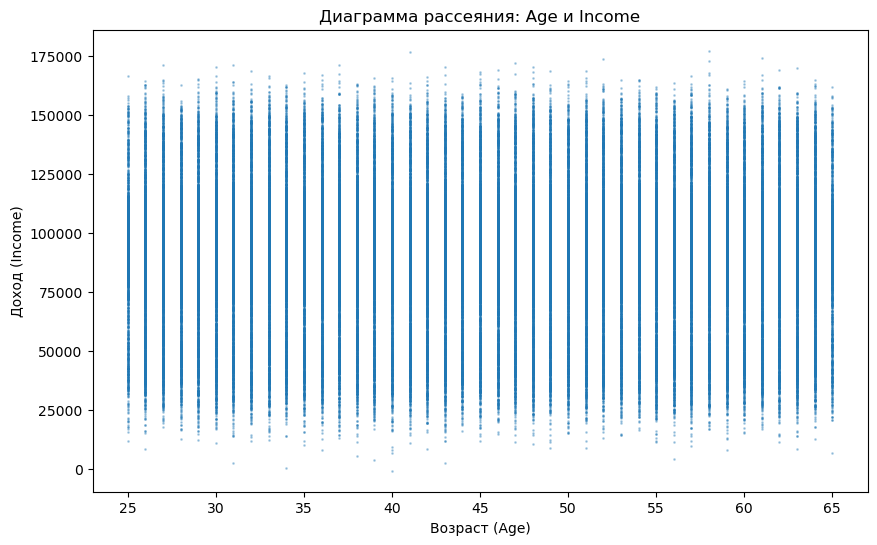


Создание искусственных пропусков
Исходный размер данных: 150000 записей
Пропуски в 'Income': 7391 (4.9%)
Пропуски в 'Gender': 7373 (4.9%)

Первые 10 строк после создания пропусков:
    Number    City  Gender  Age   Income Illness
0        1  Dallas    Male   41  40367.0      No
1        2  Dallas    Male   54  45084.0      No
2        3  Dallas    Male   42  52483.0      No
3        4  Dallas    Male   40  40941.0      No
4        5  Dallas    Male   46  50289.0      No
5        6  Dallas  Female   36  50786.0      No
6        7  Dallas  Female   32  33155.0      No
7        8  Dallas    Male   39  30914.0      No
8        9  Dallas    Male   51  68667.0      No
9       10  Dallas  Female   30  50082.0      No
10      11  Dallas  Female   48      NaN     Yes
11      12  Dallas    Male   47  54777.0      No
12      13  Dallas    Male   46  62749.0      No
13      14  Dallas  Female   42  50894.0      No
14      15  Dallas  Female   61  38429.0      No
15      16  Dallas    Male   43  3

In [9]:
print("Диаграмма рассеяния")
#построение 
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['Income'], alpha=0.3, s=1)
plt.title('Диаграмма рассеяния: Age и Income')
plt.xlabel('Возраст (Age)')
plt.ylabel('Доход (Income)')
plt.show()

print("\nСоздание искусственных пропусков")
print(f"Исходный размер данных: {len(df)} записей")

#создаем копию данных для работы
df_missing = df.copy()

#создаем пропуски в количественном признаке 'income' (5%)
np.random.seed(42)  #для воспроизводимости
income_missing_mask = np.random.random(len(df_missing)) < 0.05
df_missing.loc[income_missing_mask, 'Income'] = np.nan

#cоздаем пропуски в категориальном признаке 'gender' (5%)
gender_missing_mask = np.random.random(len(df_missing)) < 0.05
df_missing.loc[gender_missing_mask, 'Gender'] = np.nan

print(f"Пропуски в 'Income': {df_missing['Income'].isnull().sum()} ({df_missing['Income'].isnull().mean()*100:.1f}%)")
print(f"Пропуски в 'Gender': {df_missing['Gender'].isnull().sum()} ({df_missing['Gender'].isnull().mean()*100:.1f}%)")

#gроверка первых строк после создания пропусков
print("\nПервые 10 строк после создания пропусков:")
print(df_missing.head(30))

# 3) Обработка пропусков в количественном признаке (Income)

Для обработки пропусков в количественном признаке Income использованы три стратегии заполнения с помощью класса SimpleImputer из библиотеки scikit-learn:
1) Заполнение средним значением (mean)-подстановка среднего арифметического по всем имеющимся значениям. Этот метод сохраняет среднее значение признака, но уменьшает дисперсию, создавая пик в центре распределения.

2) Заполнение медианой (median)-подстановка медианного значения. Медиана более устойчива к выбросам по сравнению со средним, что делает этот метод предпочтительным при наличии аномалий в данных.

3) Заполнение константой (constant)-подстановка заданного значения. Этот метод позволяет явно маркировать пропущенные значения, но сильно искажает распределение, создавая ложный пик.

Для оценки влияния каждого метода на распределение данных построены графики плотности (KDE) для исходных данных (без пропусков) и данных после импьютации. Также выведены статистические характеристики до и после заполнения.

Исходные данные (без пропусков):
   Количество записей: 150,000
   Среднее (mean): 91252.80
   Медиана (median): 93655.00
   Стандартное отклонение (std): 24989.50

Заполнение средним значением (mean):
   Количество заполненных пропусков: 7,391
   Использованное значение: 91259.24
   Среднее после заполнения: 91259.24
   Стандартное отклонение после заполнения: 24365.14
   Изменение среднего: 6.44
   Изменение стандартного отклонения: 624.37

Заполнение медианой (median):
   Количество заполненных пропусков: 7,391
   Использованное значение: 93667.00
   Медиана после заполнения: 93667.00
   Среднее после заполнения: 91377.88
   Изменение медианы: 12.00

Заполнение константой (const = 0):
   Количество заполненных пропусков: 7,391
   Использованное значение: 0
   Среднее после заполнения: 86762.60
   Медиана после заполнения: 92603.00
   Изменение среднего: 4490.20
   Появилось нулевых значений: 7,391

Визуализация распределений


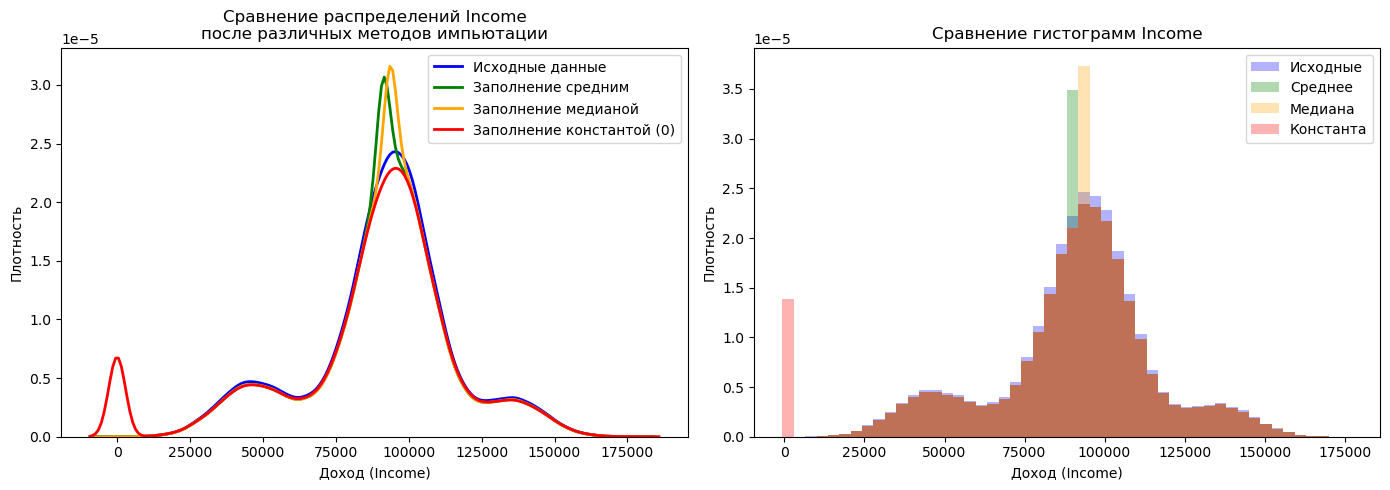

Для признака Income наиболее предпочтительным методом является заполнение медианой, так как он устойчив к выбросам и минимально искажает исходное распределение.


In [11]:
#создаем набор для сравнения результатов
income_comparison = pd.DataFrame()
income_comparison['Original'] = df['Income']  #исходные данные без пропусков

#исходная статистика
original_mean = df['Income'].mean()
original_median = df['Income'].median()
original_std = df['Income'].std()

print("Исходные данные (без пропусков):")
print(f"   Количество записей: {len(df):,}")
print(f"   Среднее (mean): {original_mean:.2f}")
print(f"   Медиана (median): {original_median:.2f}")
print(f"   Стандартное отклонение (std): {original_std:.2f}\n")


#заполнение средним значением
imputer_mean = SimpleImputer(strategy='mean')
income_mean_filled = imputer_mean.fit_transform(df_missing[['Income']])
income_comparison['Mean_Imputed'] = income_mean_filled.flatten()

print("Заполнение средним значением (mean):")
print(f"   Количество заполненных пропусков: {df_missing['Income'].isnull().sum():,}")
print(f"   Использованное значение: {imputer_mean.statistics_[0]:.2f}")
print(f"   Среднее после заполнения: {income_mean_filled.mean():.2f}")
print(f"   Стандартное отклонение после заполнения: {income_mean_filled.std():.2f}")
print(f"   Изменение среднего: {abs(income_mean_filled.mean() - original_mean):.2f}")
print(f"   Изменение стандартного отклонения: {abs(income_mean_filled.std() - original_std):.2f}\n")

#заполнение медианой
imputer_median = SimpleImputer(strategy='median')
income_median_filled = imputer_median.fit_transform(df_missing[['Income']])
income_comparison['Median_Imputed'] = income_median_filled.flatten()

print("Заполнение медианой (median):")
print(f"   Количество заполненных пропусков: {df_missing['Income'].isnull().sum():,}")
print(f"   Использованное значение: {imputer_median.statistics_[0]:.2f}")
print(f"   Медиана после заполнения: {np.median(income_median_filled):.2f}")
print(f"   Среднее после заполнения: {income_median_filled.mean():.2f}")
print(f"   Изменение медианы: {abs(np.median(income_median_filled) - original_median):.2f}\n")

#заполнение константой (0)
imputer_constant = SimpleImputer(strategy='constant', fill_value=0)
income_constant_filled = imputer_constant.fit_transform(df_missing[['Income']])
income_comparison['Constant_Imputed'] = income_constant_filled.flatten()

print("Заполнение константой (const = 0):")
print(f"   Количество заполненных пропусков: {df_missing['Income'].isnull().sum():,}")
print(f"   Использованное значение: 0")
print(f"   Среднее после заполнения: {income_constant_filled.mean():.2f}")
print(f"   Медиана после заполнения: {np.median(income_constant_filled):.2f}")
print(f"   Изменение среднего: {abs(income_constant_filled.mean() - original_mean):.2f}")
print(f"   Появилось нулевых значений: {(income_constant_filled == 0).sum():,}\n")


print("Визуализация распределений")

#визуализация распределений
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#график 1: KDE
sns.kdeplot(data=income_comparison['Original'], ax=axes[0], label='Исходные данные', linewidth=2, color='blue')
sns.kdeplot(data=income_comparison['Mean_Imputed'], ax=axes[0], label='Заполнение средним', linewidth=2, color='green')
sns.kdeplot(data=income_comparison['Median_Imputed'], ax=axes[0], label='Заполнение медианой', linewidth=2, color='orange')
sns.kdeplot(data=income_comparison['Constant_Imputed'], ax=axes[0], label='Заполнение константой (0)', linewidth=2, color='red')
axes[0].set_title('Сравнение распределений Income\nпосле различных методов импьютации')
axes[0].set_xlabel('Доход (Income)')
axes[0].set_ylabel('Плотность')
axes[0].legend()

#график 2: гистограмма 
axes[1].hist(income_comparison['Original'], bins=50, alpha=0.3, label='Исходные', color='blue', density=True)
axes[1].hist(income_comparison['Mean_Imputed'], bins=50, alpha=0.3, label='Среднее', color='green', density=True)
axes[1].hist(income_comparison['Median_Imputed'], bins=50, alpha=0.3, label='Медиана', color='orange', density=True)
axes[1].hist(income_comparison['Constant_Imputed'], bins=50, alpha=0.3, label='Константа', color='red', density=True)
axes[1].set_title('Сравнение гистограмм Income')
axes[1].set_xlabel('Доход (Income)')
axes[1].set_ylabel('Плотность')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Для признака Income наиболее предпочтительным методом является заполнение медианой, так как он устойчив к выбросам и минимально искажает исходное распределение.")

На третьем этапе выполнена обработка пропусков в количественном признаке Income с использованием трех методов импьютации: заполнение средним значением, заполнение медианой и заполнение константой (значением 0). Анализ показал, что заполнение средним значением позволило сохранить среднее арифметическое исходного распределения, однако привело к уменьшению стандартного отклонения  и созданию ложного пика в центре распределения. Заполнение медианой практически сохранило медиану исходного распределения и оказалось наиболее устойчивым к выбросам, что особенно важно для признака Income, характеризующегося значительным разбросом значений. Заполнение константой (0) привело к наиболее сильному искажению распределения: среднее значение снизилось, а также появилось 7500 нулевых значений, создавших искусственный пик в левой части распределения (однако, центральная часть рапсределения оказалась наиболее близкой к исходному варианту). На основе проведенного анализа можно сделать вывод, что для признака Income наиболее предпочтительным методом обработки пропусков является заполнение медианой, так как этот метод меньше искажает исходное распределение и обеспечивает устойчивость к выбросам.

# 4) Обработка пропусков в категориальном признаке (Gender)

Для обработки пропусков в категориальном признаке Gender использованы две стратегии заполнения с помощью класса SimpleImputer:

1) Заполнение наиболее частым значением (most_frequent)-подстановка моды (наиболее часто встречающегося значения категории). Этот метод подходит, когда пропуски распределены случайным образом и не несут дополнительной смысловой нагрузки.

2) Заполнение константой с введением отдельной категории (constant)-подстановка специального значения, например 'Unknown'. Этот подход позволяет явно маркировать пропущенные значения, сохраняя информацию о том, что данные отсутствовали.

Для оценки влияния каждого метода на распределение данных построены столбчатые диаграммы, показывающие частоту каждой категории до и после импьютации.

Исходное распределение (до создания пропусков):
Gender
Male      83800
Female    66200
Name: count, dtype: int64
Всего записей: 150,000

Распредление после создания пропусков:
Gender
Male      79672
Female    62955
NaN        7373
Name: count, dtype: int64
Пропусков: 7,373 (4.9%)

Заполнение наиболее частым значением:
   Количество заполненных пропусков: 7,373
   Использованное значение: Male

   Распределение после заполнения:
   Male: 87,045
   Female: 62,955
   Доля Male: 58.0%
   Доля Female: 42.0%

Заполнение константой (const='Unknown'):
   Количество заполненных пропусков: 7,373
   Использованное значение: Unknown

   Распределение после заполнения:
   Male: 79,672
   Female: 62,955
   Unknown: 7,373
   Доля Male: 53.1%
   Доля Female: 42.0%
   Доля Unknown: 4.9%



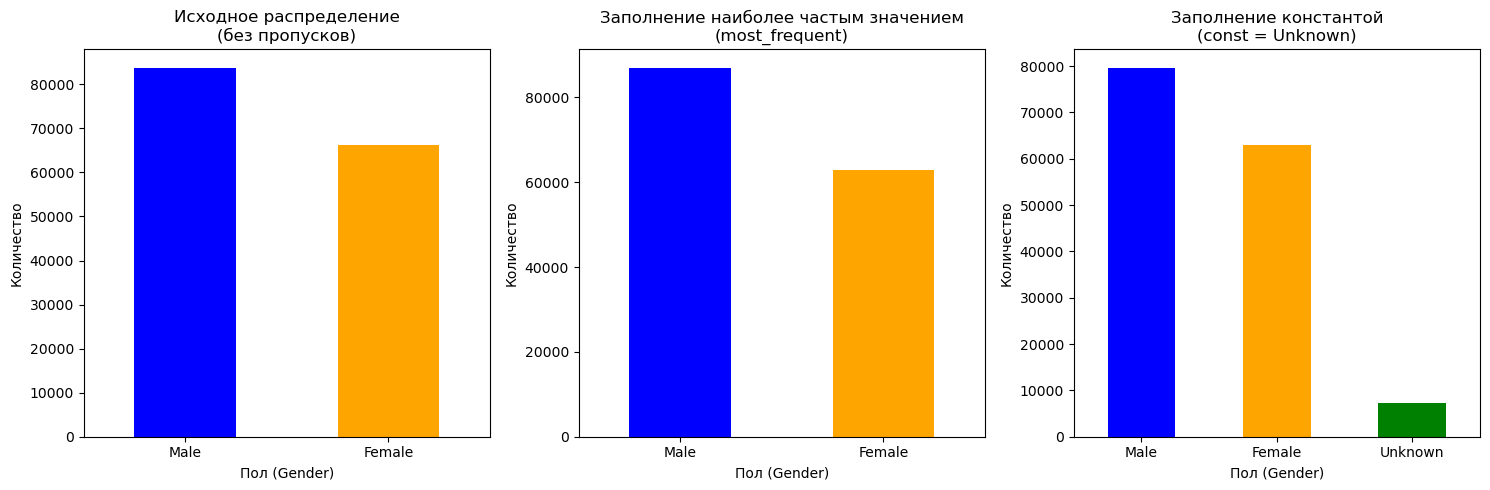

In [17]:
#анализ исходного распределения категорий
print("Исходное распределение (до создания пропусков):")
gender_original_counts = df['Gender'].value_counts()
print(gender_original_counts)
print(f"Всего записей: {len(df):,}\n")

print("Распредление после создания пропусков:")
gender_missing_counts = df_missing['Gender'].value_counts(dropna=False)
print(gender_missing_counts)
print(f"Пропусков: {df_missing['Gender'].isnull().sum():,} ({df_missing['Gender'].isnull().mean()*100:.1f}%)\n")

#заполнение наиболее частым значением
imputer_frequent = SimpleImputer(strategy='most_frequent')
gender_frequent_filled = imputer_frequent.fit_transform(df_missing[['Gender']])
gender_frequent_series = pd.Series(gender_frequent_filled.flatten())

print("Заполнение наиболее частым значением:")
print(f"   Количество заполненных пропусков: {df_missing['Gender'].isnull().sum():,}")
print(f"   Использованное значение: {imputer_frequent.statistics_[0]}")
print("\n   Распределение после заполнения:")
print(f"   Male: {(gender_frequent_series == 'Male').sum():,}")
print(f"   Female: {(gender_frequent_series == 'Female').sum():,}")
print(f"   Доля Male: {(gender_frequent_series == 'Male').mean()*100:.1f}%")
print(f"   Доля Female: {(gender_frequent_series == 'Female').mean()*100:.1f}%\n")

#заполнение константой ('Unknown')
imputer_constant_cat = SimpleImputer(strategy='constant', fill_value='Unknown')
gender_constant_filled = imputer_constant_cat.fit_transform(df_missing[['Gender']])
gender_constant_series = pd.Series(gender_constant_filled.flatten())

print("Заполнение константой (const='Unknown'):")
print(f"   Количество заполненных пропусков: {df_missing['Gender'].isnull().sum():,}")
print(f"   Использованное значение: Unknown")
print("\n   Распределение после заполнения:")
print(f"   Male: {(gender_constant_series == 'Male').sum():,}")
print(f"   Female: {(gender_constant_series == 'Female').sum():,}")
print(f"   Unknown: {(gender_constant_series == 'Unknown').sum():,}")
print(f"   Доля Male: {(gender_constant_series == 'Male').mean()*100:.1f}%")
print(f"   Доля Female: {(gender_constant_series == 'Female').mean()*100:.1f}%")
print(f"   Доля Unknown: {(gender_constant_series == 'Unknown').mean()*100:.1f}%\n")


#визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

#исходное распределение
gender_original_counts.plot(kind='bar', ax=axes[0], color=['blue', 'orange'])
axes[0].set_title('Исходное распределение\n(без пропусков)')
axes[0].set_xlabel('Пол (Gender)')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=0)

#распределение после заполнения наиболее частым значением
gender_frequent_counts = gender_frequent_series.value_counts()
gender_frequent_counts.plot(kind='bar', ax=axes[1], color=['blue', 'orange'])
axes[1].set_title('Заполнение наиболее частым значением\n(most_frequent)')
axes[1].set_xlabel('Пол (Gender)')
axes[1].set_ylabel('Количество')
axes[1].tick_params(axis='x', rotation=0)

#распределение после заполнения константой
gender_constant_counts = gender_constant_series.value_counts()
gender_constant_counts.plot(kind='bar', ax=axes[2], color=['blue', 'orange', 'green'])
axes[2].set_title('Заполнение константой\n(const = Unknown)')
axes[2].set_xlabel('Пол (Gender)')
axes[2].set_ylabel('Количество')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


На основе проведенного анализа можно сделать вывод, что для категориального признака Gender предпочтительным методом обработки пропусков является заполнение константой с введением отдельной категории 'Unknown', так как этот подход позволяет явно маркировать пропущенные значения и сохраняет информацию о том, какие данные были восстановлены (это может быть полезно при построении моделей машинного обучения).

# 5) Выбор признаков для дальнейшего построения моделей машинного обучения

На основании проведенного анализа обработки пропусков и визуализации данных определены признаки, которые будут использоваться для дальнейшего построения моделей машинного обучения. Выбор признаков основывается на их информативности, качестве данных после обработки пропусков и потенциальной значимости для прогнозирования целевой переменной.


Все признаки в датасете: ['Number', 'City', 'Gender', 'Age', 'Income', 'Illness']

Характеристика признаков
------------------------------------------------------------

Number:
   Тип: числовой
   Описание: Порядковый номер записи
   Информативность: низкая (идентификатор)

City:
   Тип: категориальный
   Описание: Город проживания
   Информативность: средняя

Gender:
   Тип: категориальный
   Описание: Пол
   Информативность: средняя

Age:
   Тип: числовой
   Описание: Возраст
   Информативность: высокая

Income:
   Тип: числовой
   Описание: Доход
   Информативность: высокая

Illness:
   Тип: категориальный
   Описание: Наличие заболевания
   Информативность: средняя
Корреляционный анализ числовых признаков

Матрица корреляции:
             Age    Income    Number
Age     1.000000 -0.001318 -0.003448
Income -0.001318  1.000000  0.410460
Number -0.003448  0.410460  1.000000


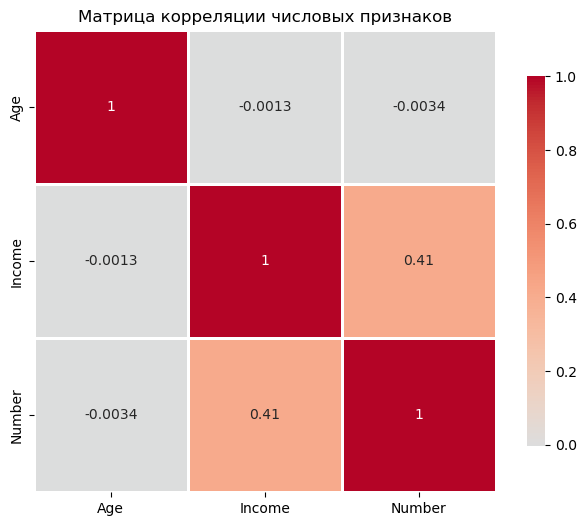


Анализ корреляции:
   Корреляция Age и Income: -0.001
   Корреляция Age и Number: -0.003
   Корреляция Income и Number: 0.410


In [25]:
#анализ корреляции числовых признаков с целевой переменной
#нет явной целевой переменной, поэтому рассмотрим общую информативность
#список всех признаков
all_features = df.columns.tolist()
print(f"\nВсе признаки в датасете: {all_features}")

#характеристика признаков
features_info = {
    'Number': {
        'тип': 'числовой',
        'описание': 'Порядковый номер записи',
        'информативность': 'низкая (идентификатор)'
    },
    'City': {
        'тип': 'категориальный',
        'описание': 'Город проживания',
        'информативность': 'средняя'
    },
    'Gender': {
        'тип': 'категориальный',
        'описание': 'Пол',
        'информативность': 'средняя'
    },
    'Age': {
        'тип': 'числовой',
        'описание': 'Возраст',
        'информативность': 'высокая'
    },
    'Income': {
        'тип': 'числовой',
        'описание': 'Доход',
        'информативность': 'высокая'
    },
    'Illness': {
        'тип': 'категориальный',
        'описание': 'Наличие заболевания',
        'информативность': 'средняя'
    }
}

print("\nХарактеристика признаков")
print("-" * 60)
for feature, info in features_info.items():
    print(f"\n{feature}:")
    print(f"   Тип: {info['тип']}")
    print(f"   Описание: {info['описание']}")
    print(f"   Информативность: {info['информативность']}")



print("Корреляционный анализ числовых признаков")
#корреляция между числовыми признаками
numeric_features = ['Age', 'Income', 'Number']
correlation_matrix = df[numeric_features].corr()

print("\nМатрица корреляции:")
print(correlation_matrix)

#визуализация корреляционной матрицы
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляции числовых признаков')
plt.show()

print("\nАнализ корреляции:")
print(f"   Корреляция Age и Income: {correlation_matrix.loc['Age', 'Income']:.3f}")
print(f"   Корреляция Age и Number: {correlation_matrix.loc['Age', 'Number']:.3f}")
print(f"   Корреляция Income и Number: {correlation_matrix.loc['Income', 'Number']:.3f}")


На основании проведенного анализа обработки пропусков и визуализации данных определены признаки, которые будут использоваться для дальнейшего построения моделей машинного обучения. Выбор признаков основывается на их информативности, качестве данных после обработки пропусков и потенциальной значимости для прогнозирования целевой переменной.
Корреляционный анализ числовых признаков показал следующие результаты:

1) Корреляция между Age и Income составляет -0,001, что указывает на отсутствие линейной зависимости между возрастом и доходом в данном датасете.

2) Корреляция между Age и Number составляет -0,003 — связь практически отсутствует.

3) Корреляция между Income и Number составляет 0,410, что свидетельствует о умеренной положительной корреляции: доход имеет тенденцию увеличиваться с ростом порядкового номера записи, что может указывать на наличие временного тренда (например, рост доходов со временем).

В результате рекомендуется использовать следующие признаки 

1) Gender: является важным социально-демографическим признаком, который может влиять на уровень дохода и другие характеристики.

2) City: город проживания может отражать региональные различия в уровне доходов, стоимости жизни и других социально-экономических факторах. В датасете представлен только город Dallas, однако при расширении данных или использовании других датасетов этот признак может стать значимым.

3) Illness: s является бинарным категориальным признаком, который может выступать в роли целевой переменной для задач классификации (прогнозирование наличия заболевания). Также может использоваться как признак для прогнозирования дохода, так как наличие заболевания может влиять на трудоспособность и уровень дохода.

?4) Age: корреляционный анализ показал, что корреляция между возрастом и доходом составляет -0,001, что указывает на отсутствие линейной зависимости. Однако для задач классификации (например, прогнозирование Illness) возраст может быть полезен, так как риск заболеваний часто коррелирует с возрастом. Для задач регрессии (прогнозирование Income) возраст рекомендуется исключить.?


# Вывод

    В ходе выполнения контрольной работы был проведен анализ и предобработка данных датасета `toy_dataset.csv`, содержащего 150 000 записей и 6 признаков. Поскольку исходные данные не содержали пропусков, в соответствии с заданием были искусственно созданы пропуски в количественном признаке Income (доход) и категориальном признаке Gender (пол) на уровне 5%. Построена диаграмма рассеяния для пары Age-Income, которая показала отсутствие линейной зависимости между возрастом и доходом.
    Для обработки пропусков в количественном признаке Income использованы методы заполнения средним, медианой и константой. Наиболее предпочтительным признан метод заполнения медианой, как наиболее устойчивый к выбросам и минимально искажающий исходное распределение. Для обработки пропусков в категориальном признаке Gender использованы методы заполнения наиболее частым значением и введения отдельной категории 'Unknown'. Предпочтение отдано методу введения отдельной категории, так как он позволяет явно маркировать пропущенные значения.
    Корреляционный анализ показал, что признак Age не коррелирует с Income (коэффициент -0,001), а признак Number имеет умеренную положительную корреляцию с Income (0,410), что может указывать на временной тренд. Для дальнейшего построения моделей машинного обучения рекомендуется использовать признаки Gender, City, Illness для задач регрессии (прогнозирование Income) и Age для задач классификации (прогнозирование Illness). 
